In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from skyfield.api import EarthSatellite, load, wgs84, Topos
from datetime import datetime, timezone, timedelta

Re     = 6371.0       # km (tính toán hình học)
Re_tle = 6378.137     # km WGS84 (sinh TLE)
mu     = 398600.4418  # km³/s²

# ── Vùng phủ mục tiêu: Việt Nam ──────────────────────────────
VN_LAT_MIN, VN_LAT_MAX = 8.0,  23.5   # dải vĩ độ Việt Nam
VN_LON_MIN, VN_LON_MAX = 102.0, 110.0  # dải kinh độ Việt Nam

# ── Tham số hệ thống ──────────────────────────────────────────
EL_MIN_DEG          = 10.0    # góc ngưỡng nhìn thấy vệ tinh (độ)
VOIP_MAX_LATENCY_MS = 150.0   # ngưỡng VoIP
MIN_CONTACT_SEC     = 300     # thời gian tiếp xúc tối thiểu (s)
IMAGING_MIN_DATA_GB = 1.0     # dung lượng ảnh tối thiểu/lần qua


/home/lunog/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Tính singele coverage
Một vệ tinh ở độ cao h và half beam angle $\alpha$ có khả năng bao phủ một phần hình cầu trên bề mặt Trái Đất , nửa góc hình nón tính theo tâm Trái Đất của vùng phủ sóng được gọi là góc phủ sóng $\theta$

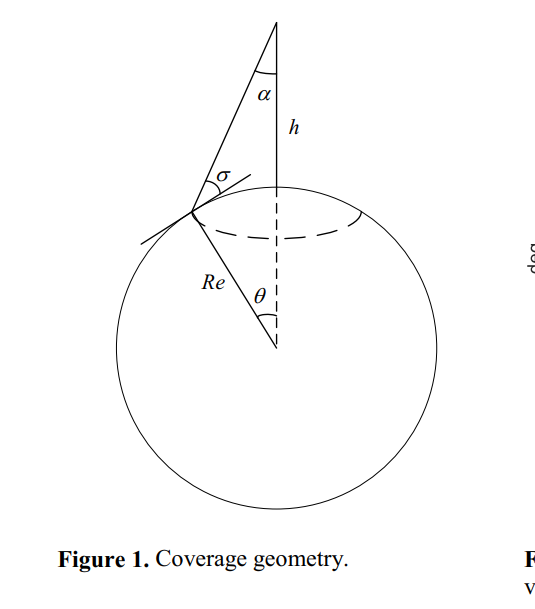

$$ \mathbf{\theta = \arcsin\left(\frac{h + Re}{Re}\sin\alpha\right) - \alpha} \tag {1}$$

In [2]:
def coverage_angle(h, alpha_deg):
    """Góc phủ geocentric (theta) từ độ cao h và half-beam angle alpha."""
    a   = np.radians(alpha_deg)
    arg = np.clip((h + Re) / Re * np.sin(a), -1.0, 1.0)
    return np.degrees(np.arcsin(arg) - a)


## 1 SoC Method

### Quan hệ của street width $\psi$ số vệ tinh trên mỗi mặt phẳng $n_2$ và góc phủ $\theta$

**Eq.(4) — Quan hệ θ, ψ, n₂:**
$$\cos\theta = \cos\psi \cdot \cos\!\left(\frac{\pi}{n_2}\right)$$

**Eq.(10) — n₂ tối thiểu:**
$$n_2 \ge \frac{\pi}{\arccos(\cos\theta / \cos\psi_{\min})}$$

**Eq.(11) — Tổng vệ tinh:** $N = n_1 \cdot n_2$ với n1 là số lượng mặt phẳng


In [3]:
def n2_required(theta_deg, psi_min_deg):
    """Số vệ tinh tối thiểu/mặt phẳng để đảm bảo street width >= psi_min."""    
    ct = np.cos(np.radians(theta_deg))
    cp = np.cos(np.radians(psi_min_deg))
    if cp <= 0 or ct / cp >= 1.0:
        return 999
    return int(np.ceil(np.pi / np.arccos(ct / cp)))


## 1.1 Symmetrical polar

**Eq.(12):** $\psi_{\min} = \dfrac{\pi}{2n_1}$

In [4]:
def soc_polar_sym(h, alpha_deg,
                  phi_min_deg=0.0, phi_max_deg=90.0,
                  n1_range=range(3, 120)):
    """
    Symmetrical polar constellation.

    Khi phi_min_deg > 0 (ví dụ Việt Nam: phi_min=8°, phi_max=23.5°),
    không cần phủ liên tục từ xích đạo nên ràng buộc psi_min nới lỏng:
      - Nếu phi_min == 0  → psi_min = pi/(2*n1)  (phải phủ xích đạo)
      - Nếu phi_min > 0   → chỉ cần phủ dải [phi_min, phi_max]
        => psi_min = pi/(2*n1) * cos(phi_min)  (xấp xỉ — xích đạo không cần)
        Thực tế: dùng điều kiện street width tại vĩ độ phi_min
    """
    theta = coverage_angle(h, alpha_deg)

    best = {"N": float("inf")}
    for n1 in n1_range:
        if phi_min_deg == 0.0:
            # Cần phủ xích đạo → psi_min = pi/(2*n1)
            psi_deg = np.degrees(np.pi / (2 * n1))
        else:
            # Không cần phủ xích đạo.
            # Street width yêu cầu tại vĩ độ phi_min:
            #   psi_min ≥ pi/(2*n1) * cos(phi_min)  [scaled by cos(lat)]
            # Đây là xấp xỉ bảo thủ; thực tế psi_min có thể nhỏ hơn.
            psi_deg = np.degrees(np.pi / (2 * n1)) * np.cos(np.radians(phi_min_deg))

        if theta <= psi_deg:
            continue

        n2 = n2_required(theta, psi_deg)
        N  = n1 * n2
        if N < best["N"]:
            best = {"N": N, "n1": n1, "n2": n2,
                    "psi_min": psi_deg, "theta": theta}
    return best


###  1.2 Non - symmertrical polar

**Eq.(14)** $\Delta_1 = \theta + \psi$ (co-rotating interface)

**Eq.(15):** $\Delta_2 = 2\psi$ (counter-rotating interface)

**Eq.(16):** $\Delta_3 = (n_1 - 1)\Delta_1 + \Delta_2 = \pi$

**Eq.(17):** Suy ra $\psi_{min} =  \frac{n_1 - 1}{n_1 + 1}\,\theta$ 



In [5]:
def soc_polar_nonsym(h, alpha_deg,
                     phi_min_deg=0.0, phi_max_deg=90.0,
                     n1_range=range(3, 120)):
    """
    Non-symmetrical polar constellation.

    Tương tự sym nhưng sử dụng Eq.(17) của paper:
      psi_min = (pi - (n1-1)*theta) / (n1+1)   [counter-rotating interface]

    Khi phi_min_deg > 0: street không cần bao phủ xích đạo,
    nên có thể dùng n1 nhỏ hơn mà vẫn đảm bảo phủ [phi_min, phi_max].
    Ràng buộc bổ sung: theta * n1 > pi/2 * cos(phi_min) (thay vì pi/2).
    """
    theta     = coverage_angle(h, alpha_deg)
    theta_rad = np.radians(theta)

    # Vùng xích đạo hay phi_min?
    lat_constraint_rad = np.radians(phi_min_deg) if phi_min_deg > 0 else 0.0

    best = {"N": float("inf")}
    for n1 in n1_range:
        # Điều kiện đủ để tạo được street tại vĩ độ lat_constraint
        if n1 * theta_rad <= np.pi / 2 * np.cos(lat_constraint_rad):
            continue

        psi_rad = (np.pi - (n1 - 1) * theta_rad) / (n1 + 1)
        if psi_rad <= 0:
            continue
        psi_deg = np.degrees(psi_rad)

        if theta <= psi_deg:
            continue

        n2 = n2_required(theta, psi_deg)
        N  = n1 * n2
        if N < best["N"]:
            best = {"N": N, "n1": n1, "n2": n2,
                    "psi_min": psi_deg, "theta": theta}
    return best


### 1.3 Inclined orbit

**Eq (5)**  $\phi_j = \arctan[\tan i\,\cos(j\pi/n_1)]$

**Eq (6)**  $\sin \psi_{min.m} = \sin X_U\,\cos i / \cos \phi_{m-1}$

**Eq (7)** $X_U = \arctan\{\sin(\frac{m\pi}{n_1})\,\sin(\frac{\pi}{n_1})\,\tan i \{1 + \cos(\frac{m\pi}{n_1}) \, \cos(\frac{\pi}{n_1}) \cos [(m-1)\frac{pi}{n_1}] \,\tan^2 i\}^{-1}\}$

**Eq.(8):** $\psi_{\text{ext}} = \arcsin[\sin\phi_{\max}\cos i - \cos\phi_{\max}\sin i\cos(\pi/n_1)]$ (vùng ngoài mesh)

**Eq.(9):** $\psi_{\min} = \max(\psi_{\min,1},\ldots,\psi_{\text{ext}})$




In [6]:
def soc_inclined_vn(h, alpha_deg,
                    phi_min_deg=VN_LAT_MIN,
                    phi_max_deg=VN_LAT_MAX,
                    n1_range=range(3, 60)):
    """
    Inclined orbit constellation cho dải [phi_min_deg, phi_max_deg].

    Thay đổi so với paper gốc (phi_min=0):
    - Chỉ tính psi_min,m cho các mesh layer nằm trong [phi_min, phi_max].
    - Loại bỏ các mesh layer hoàn toàn dưới phi_min khỏi ràng buộc.
    - psi_ext vẫn được tính nếu phi_max > phi_1.
    """
    theta   = coverage_angle(h, alpha_deg)
    best    = {"N": float("inf")}

    phi_min = np.radians(phi_min_deg)
    phi_max = np.radians(phi_max_deg)

    for i_deg in np.arange(phi_max_deg + 1, 86, 1.0):
        i = np.radians(i_deg)

        for n1 in n1_range:
            # Vĩ độ các nút lưới theo Eq.(5)
            phi_j = [np.arctan(np.tan(i) * np.cos(j * np.pi / n1))
                     for j in range(1, n1)]
            phi_1_deg = np.degrees(phi_j[0]) if phi_j else i_deg

            psi_mesh = []
            for m in range(1, n1):
                # Vĩ độ lớp m và m-1
                phi_m   = phi_j[m - 1]      # phi_m (vĩ độ hàng m)
                phi_pm1 = phi_j[m - 2] if m >= 2 else i  # phi_{m-1}

                # ── Loại bỏ mesh hoàn toàn bên dưới phi_min ──────────
                # Tâm mesh tại ~ (phi_m + phi_pm1) / 2
                # Nếu cả hai đỉnh đều dưới phi_min → bỏ qua
                if phi_pm1 < phi_min and phi_m < phi_min:
                    continue

                mpi_n1 = m * np.pi / n1
                pi_n1  = np.pi / n1
                num = np.sin(mpi_n1) * np.sin(pi_n1) * np.tan(i)
                den = 1 + (np.cos(mpi_n1) * np.cos(pi_n1) *
                           np.cos((m - 1) * pi_n1) * np.tan(i) ** 2)
                if abs(den) < 1e-12:
                    continue
                X_U = np.arctan(num / den)
                sp  = np.clip(np.sin(X_U) * np.cos(i) / np.cos(phi_pm1), -1, 1)
                psi_mesh.append(np.degrees(np.arcsin(sp)))

            # ── psi_ext: phủ vùng ngoài lưới (phi_max > phi_1) ──────
            if phi_max_deg > phi_1_deg:
                term    = (np.sin(phi_max) * np.cos(i) -
                           np.cos(phi_max) * np.sin(i) * np.cos(np.pi / n1))
                psi_ext = np.degrees(np.arcsin(np.clip(term, -1, 1)))
                psi_min = max(max(psi_mesh) if psi_mesh else 0, psi_ext)
            else:
                psi_min = max(psi_mesh) if psi_mesh else 0

            if theta <= psi_min:
                continue
            n2 = n2_required(theta, psi_min)
            N  = n1 * n2
            if N < best["N"]:
                best = {"N": N, "n1": n1, "n2": n2,
                        "i": i_deg, "psi_min": psi_min, "theta": theta}
    return best


## 2. Tiêu chí thiết kế & Tính toán ràng buộc

Hệ thống VNU-LEO phục vụ **2 bài toán** với tiêu chí độc lập:

| Bài toán | Tiêu chí | Ngưỡng |
|----------|----------|--------|
| Internet / VoIP | Độ trễ một chiều | < 150 ms (ITU-T G.114) |
| Ảnh / Radar thời tiết | Dữ liệu truyền được / pass | ≥ 1 GB/pass |

---

### 2.1 Độ trễ truyền sóng (VoIP)

Độ trễ một chiều xấp xỉ theo khoảng cách vệ tinh–mặt đất:

$$\text{latency} = \frac{2h}{c} \times 1000 \quad \text{(ms)}$$

Ngưỡng **150 ms** theo tiêu chuẩn ITU-T G.114 cho VoIP — tương đương độ cao tối đa ~**22,500 km**, nhưng thực tế LEO (<1500 km) luôn thỏa mãn dễ dàng.

---

### 2.2 Link Budget — Downlink X-band

**Thông số hệ thống:**

| Tham số | Giá trị | Ghi chú |
|---------|---------|---------|
| Tần số | 8.0 GHz | X-band, chuẩn quan sát Trái Đất |
| Công suất phát | 5 W | Vệ tinh LEO nhỏ |
| Gain anten phát | 6 dBi | Patch/horn nhỏ trên vệ tinh |
| Đường kính anten thu | 0.6 m | Dish tracking tại gateway |
| Hiệu suất anten | 0.55 | Điển hình cho dish parabol |
| Noise temperature | 150 K | System noise |
| Băng thông kênh | 50 MHz | X-band typical |
| Link margin | 3 dB | Dự phòng thời tiết, nhiễu |
| Elevation tối thiểu | 10° | Góc ngẩng tối thiểu |

**Chuỗi tính toán:**

$$\text{Slant range}: \quad d = \sqrt{(R_e+h)^2 - R_e^2\cos^2\varepsilon} - R_e\sin\varepsilon$$

$$\text{EIRP} = P_{tx}(\text{dBW}) + G_{tx}(\text{dBi})$$

$$\text{FSPL} = 20\log_{10}\!\left(\frac{4\pi d}{\lambda}\right)$$

$$\text{C/N}_0 = \text{EIRP} - \text{FSPL} + G_{rx} - 10\log_{10}T_{sys} - k$$

$$\text{Throughput} = B \cdot \log_2(1 + \text{SNR}) - \text{margin}$$

---

### 2.3 Dữ liệu truyền được mỗi pass

Kết hợp throughput từ link budget với thời gian tiếp xúc:

$$t_{contact} = \frac{2\rho \cdot a}{v_{orb}}, \quad \rho = \arccos\!\left(\frac{R_e}{a}\cos\varepsilon\right) - \varepsilon$$

$$\text{Data/pass} = \frac{\text{Throughput (Mbps)} \times t_{contact}}{8 \times 1000} \quad \text{(GB)}$$

Ngưỡng **1 GB/pass** đảm bảo truyền đủ 1 scene ảnh quang học (~500 MB–1 GB) hoặc radar thời tiết trong một lần bay qua.

---

### 2.4 Sweep altitude & Chọn altitude tối ưu

`ref_altitude()` quét toàn bộ h = 400..1500 km, tại mỗi độ cao tính song song:
- 3 phương án chòm sao: non-sym polar, sym polar, inclined
- Latency và link budget

`pick_optimal()` lọc theo thứ tự ưu tiên:

```
both_ok (voip + imaging)  →  chọn N nhỏ nhất
    ↓ không có
voip_ok                   →  chọn N nhỏ nhất
    ↓ không có
imaging_ok                →  chọn N nhỏ nhất
    ↓ không có
tất cả rows               →  chọn N nhỏ nhất
```

In [7]:
# ── Hằng số link budget ───────────────────────────────────────
FREQ_GHZ   = 13.0    # Ku-band
BW_MHZ     = 250.0
TX_POWER_W = 10.0
GT_DB      = 5.0     # G/T mặt đất
IMPL_LOSS  = 3.0     # dB implementation loss

def latency_ms(h_km, el_deg=EL_MIN_DEG):
    """Độ trễ một chiều (ms) tính theo khoảng cách xiên."""    
    c_ms  = 299.792  # km/ms
    el_r  = math.radians(el_deg)
    slant = (math.sqrt((Re + h_km)**2 - Re**2 * math.cos(el_r)**2)
             - Re * math.sin(el_r))
    return round(slant / c_ms, 2)

def contact_time_sec(h_km, el_min_deg=EL_MIN_DEG):
    """Thời gian tiếp xúc với một điểm mặt đất (s)."""    
    a   = (Re + h_km) * 1e3
    v   = math.sqrt(3.986e14 / a)
    el_r = math.radians(el_min_deg)
    rho  = math.acos(Re * 1e3 / a * math.cos(el_r)) - el_r
    arc  = 2 * rho * a
    return round(arc / v, 1)

def link_budget(h_km, freq_ghz=FREQ_GHZ):
    """Tính throughput ước lượng (Mbps) từ link budget đơn giản."""    
    c      = 3e5        # km/s
    lam    = c / (freq_ghz * 1e6)          # bước sóng (km)
    slant  = latency_ms(h_km) * 299.792    # km
    fspl   = 20 * math.log10(4 * math.pi * slant / lam)
    snr_db = (10 * math.log10(TX_POWER_W) + GT_DB - fspl
              - IMPL_LOSS + 228.6
              - 10 * math.log10(BW_MHZ * 1e6))
    snr    = 10 ** (snr_db / 10)
    tp     = BW_MHZ * 1e6 * math.log2(1 + snr) / 1e6
    return {"throughput_mbps": round(tp, 1), "snr_db": round(snr_db, 2)}

def data_per_pass_gb(h_km):
    lb      = link_budget(h_km)
    ct      = contact_time_sec(h_km)
    data_gb = round(lb["throughput_mbps"] * ct / 8000, 3)
    return data_gb, lb["throughput_mbps"], ct

def orbit_period_min(h_km):
    a = (Re + h_km) * 1e3
    return 2 * math.pi * math.sqrt(a**3 / 3.986e14) / 60.0

def ref_altitude(alpha_deg=32, altitudes=None,
                 phi_min_deg=VN_LAT_MIN, phi_max_deg=VN_LAT_MAX):
    """Tính số vệ tinh cho tất cả phương án theo độ cao."""    
    if altitudes is None:
        altitudes = list(range(400, 1600, 100))
    rows = []
    for h in altitudes:
        r_ns  = soc_polar_nonsym(h, alpha_deg, phi_min_deg, phi_max_deg)
        r_sym = soc_polar_sym   (h, alpha_deg, phi_min_deg, phi_max_deg)
        r_inc = soc_inclined_vn (h, alpha_deg, phi_min_deg, phi_max_deg)
        lat        = latency_ms(h)
        contact_s  = contact_time_sec(h)
        data_gb, throughput_mbps, _ = data_per_pass_gb(h)

        rows.append({
            "h": h,
            "theta": r_ns.get("theta", 0),
            "latency": lat,
            "contact_sec": contact_s,
            "throughput_mbps": throughput_mbps,   # <-- thêm dòng này
            "data_gb": data_gb,                   # nên thêm luôn
            "voip_ok": lat <= VOIP_MAX_LATENCY_MS,
            "imaging_ok": data_gb >= IMAGING_MIN_DATA_GB,
            "nonsym": r_ns,
            "sym": r_sym,
            "inclined": r_inc,
        })
    return rows

def pick_optimal(rows):
    """Chọn altitude tối ưu: N nhỏ nhất, ưu tiên thoả cả VoIP & Imaging."""    
    for r in rows:
        best_N, best_type, best_cfg = float("inf"), None, None
        for key in ("nonsym", "sym", "inclined"):
            N = r[key].get("N", float("inf"))
            if N < best_N:
                best_N, best_type, best_cfg = N, key, r[key]
        r["best_N"], r["best_type"], r["best_cfg"] = best_N, best_type, best_cfg

    for cond in (
        lambda r: r["voip_ok"] and r["imaging_ok"],
        lambda r: r["voip_ok"],
        lambda r: r["imaging_ok"],
        lambda r: True,
    ):
        pool = [r for r in rows if cond(r) and r["best_N"] < float("inf")]
        if pool:
            return min(pool, key=lambda r: r["best_N"])
    return min(rows, key=lambda r: r["best_N"])


## 3. Sinh TLE cho chòm sao 

### 3.1 Định dạng TLE

**Two-Line Element (TLE)** là định dạng chuẩn quốc tế (NORAD) mô tả quỹ đạo vệ tinh, gồm 3 dòng:

```
VNULEO-0001          ← Tên vệ tinh
1 00001U 26001A   26001.50000000  .00000000  00000-0  00000-0 0  9990   ← Line 1
2 00001  90.0000   0.0000 0000001 000.0000   0.0000 15.12345678    10   ← Line 2
```

| Trường | Line 1 | Line 2 |
|--------|--------|--------|
| Catalog number | `sid` (5 chữ số) | `sid` |
| Epoch | `26001.5` = ngày 1/2026, 12:00 UTC | — |
| Inclination | — | `i_deg` (°) |
| RAAN | — | `raan_deg mod 360` (°) |
| Eccentricity | — | `0000001` ≈ 0 (quỹ đạo tròn) |
| Arg. of perigee | — | `000.0000` (cố định) |
| Mean anomaly | — | `nu_deg mod 360` (°) |
| Mean motion | — | $n = \frac{\sqrt{\mu/a^3}}{2\pi} \times 86400$ (vòng/ngày) |

> **Lưu ý:** Checksum cuối mỗi dòng đang hardcode = 0. Skyfield/SGP4 vẫn đọc được nhưng các công cụ kiểm tra TLE nghiêm ngặt sẽ báo lỗi.

---

### 3.2 Cấu trúc chòm sao Walker Star (Non-symmetrical)

Hàm `build_constellation_tle` xây dựng chòm sao **n1 × n2** vệ tinh theo kiểu **Walker Star**:

$$\text{RAAN}_k = k \times \frac{180°}{n_1}, \quad k = 0, 1, \ldots, n_1-1$$

Các mặt phẳng trải đều trong **[0°, 180°)** — đặc trưng của Walker Star với quỹ đạo gần cực (i ≈ 90°).

**Phase offset tại seam plane:**

Mặt phẳng cuối ($k = n_1 - 1$) tiếp giáp mặt phẳng đầu nhưng bay **ngược chiều**, tạo khe hở phủ sóng (seam). Bù pha $\Delta\phi = 180°/n_2$ giúp lấp khe hở này:

$$\nu_j = j \times \frac{360°}{n_2} + \Delta\phi, \quad \Delta\phi = \begin{cases} 180°/n_2 & k = n_1-1 \text{ (nonsym)} \\ 0 & \text{otherwise} \end{cases}$$

```
Mặt phẳng 0:      ●   ●   ●   ●      phase = 0°
Mặt phẳng 1:      ●   ●   ●   ●      phase = 0°
Mặt phẳng n1-1:     ●   ●   ●   ●    phase = 180°/n2  ← seam bù pha
```

**Tham số đầu vào:**

| Tham số | Ý nghĩa | Mặc định |
|---------|---------|---------|
| `n1` | Số mặt phẳng quỹ đạo | từ `pick_optimal` |
| `n2` | Số vệ tinh / mặt phẳng | từ `pick_optimal` |
| `h_km` | Độ cao quỹ đạo (km) | từ `pick_optimal` |
| `i_deg` | Góc nghiêng (°) | `90.0` (Walker Star) |
| `nonsym` | Bật bù pha tại seam | `True` |

**Đầu ra:** Danh sách `(name, line1, line2)` cho toàn bộ $N = n_1 \times n_2$ vệ tinh.

In [8]:
def make_tle(sid, i_deg, raan_deg, nu_deg, h_km):
    """Tạo TLE (Two-Line Element) cho một vệ tinh."""    
    a = Re_tle + h_km
    n = np.sqrt(mu / a**3) * 86400 / (2 * np.pi)
    l1 = (f"1 {sid:05d}U 26001A   26001.50000000"
          f"  .00000000  00000-0  00000-0 0  9990")
    l2 = (f"2 {sid:05d} {i_deg:08.4f} {raan_deg % 360:08.4f}"
          f" 0000001 000.0000 {nu_deg % 360:08.4f} {n:011.8f}{sid:5d}0")
    return f"VNULEO-{sid:04d}", l1, l2

def build_constellation_tle(n1, n2, h_km, i_deg=90.0, nonsym=True):
    """Sinh toàn bộ TLE cho chòm sao."""    
    sats, sid = [], 1
    for k in range(n1):
        raan  = k * 180.0 / n1
        phase = (180.0 / n2) if (nonsym and k == n1 - 1) else 0.0
        for j in range(n2):
            nu = j * 360.0 / n2 + phase
            sats.append(make_tle(sid, i_deg, raan, nu, h_km))
            sid += 1
    return sats

def get_positions(tle_list, ts, t):
    """Lấy vị trí (lat, lon, alt_km) của tất cả vệ tinh tại thời điểm t."""    
    pos = []
    for name, l1, l2 in tle_list:
        sp = wgs84.subpoint(EarthSatellite(l1, l2, name, ts).at(t))
        pos.append((sp.latitude.degrees, sp.longitude.degrees, sp.elevation.km))
    return pos


## 4. Kiểm chứng phủ sóng bằng Skyfield 

### 4.1 Tổng quan

Sau khi sinh TLE, hệ thống được kiểm chứng bằng thư viện **Skyfield** với propagator **SGP4** — chuẩn công nghiệp để tính vị trí vệ tinh theo thời gian thực.

Quy trình:

```
TLE list → SGP4 propagate → vị trí (lat, lon) tại t
                                      ↓
                        so sánh góc với lưới điểm VN
                                      ↓
                        ma trận covered[lat, lon] = True/False
                                      ↓
                        lặp qua 1 chu kỳ quỹ đạo → timeline coverage
```

---

### 4.2 Lưới kiểm tra

Vùng Việt Nam được rời rạc hóa thành lưới **0.5° × 0.5°**:

| Thông số | Giá trị |
|----------|---------|
| Vĩ độ | 8.0°N → 23.5°N |
| Kinh độ | 102.0°E → 110.0°E |
| Bước lưới | 0.5° (~55 km) |
| Số điểm | ~31 × 17 ≈ 527 điểm |

---

### 4.3 Thuật toán kiểm tra phủ sóng (`check_coverage_vn`)

Với mỗi vệ tinh tại vị trí $(\phi_s, \lambda_s)$, một điểm mặt đất $(\phi, \lambda)$ được coi là **được phủ** nếu góc trung tâm Trái Đất $\alpha$ thỏa mãn:

$$\alpha = \arccos\left(\sin\phi_s \sin\phi + \cos\phi_s \cos\phi \cos(\lambda - \lambda_s)\right) \leq \theta$$

trong đó $\theta$ là **coverage half-angle** tính từ độ cao thực tế của vệ tinh.

Toàn bộ lưới được tính song song bằng **NumPy broadcasting** — không dùng vòng lặp lồng nhau:

```python
cos_a = (np.sin(slr) * np.sin(lats_r) +
         np.cos(slr) * np.cos(lats_r) * np.cos(lons_r - slnr))
covered |= (np.degrees(np.arccos(np.clip(cos_a, -1, 1))) <= theta_deg)
```

---

### 4.4 Mô phỏng theo thời gian (`verify_vn`)

Hàm lấy mẫu **n_steps = 24 thời điểm** đều nhau trong **1 chu kỳ quỹ đạo** $T_{orbit}$:

$$\Delta t = \frac{T_{orbit}}{24}$$

Tại mỗi thời điểm $t_i$:
1. SGP4 propagate toàn bộ TLE → danh sách vị trí vệ tinh
2. Kiểm tra phủ sóng trên lưới VN → `covered[lat, lon]`
3. Tính tỉ lệ phủ: $\text{coverage}(\%) = \frac{\text{số điểm covered}}{\text{tổng điểm}} \times 100$

Song song, link budget được tính tại độ cao `h_km` để kiểm chứng khả năng truyền dữ liệu:

$$\text{Data/pass} = \frac{\text{Throughput (Mbps)} \times t_{contact}}{8 \times 1000} \quad \text{(GB)}$$

**Kết quả trả về:**

| Key | Ý nghĩa |
|-----|---------|
| `avg_pct` | Coverage trung bình cả chu kỳ (%) |
| `min_pct` | Coverage thấp nhất tại 1 thời điểm (%) |
| `full_pct` | Tỉ lệ thời gian đạt ≥ 99% coverage (%) |
| `T_orbit_min` | Chu kỳ quỹ đạo (phút) |
| `timeline` | Danh sách coverage (%) tại từng bước thời gian |
| `throughput_mbps` | Throughput downlink X-band (Mbps) |
| `contact_sec` | Thời gian tiếp xúc trung bình mỗi pass (giây) |
| `data_per_pass_gb` | Dữ liệu truyền được mỗi pass (GB) |
| `imaging_ok` | `True` nếu data/pass ≥ 1 GB — đủ cho 1 scene ảnh |

In [9]:
# ── Skyfield timescale (tái sử dụng) ─────────────────────────
_ts = load.timescale()

def check_coverage_skyfield(tle_list, t_sf,
                             lats, lons,
                             el_min_deg=EL_MIN_DEG,
                             lat_min=VN_LAT_MIN, lat_max=VN_LAT_MAX):
    """
    Kiểm tra phủ sóng bằng Skyfield (elevation angle thực sự).

    Với mỗi điểm lưới (lat, lon):
      - Tính elevation angle từ điểm đó đến từng vệ tinh
      - Điểm được phủ nếu có ít nhất 1 vệ tinh có el >= el_min_deg
      - Chỉ tính điểm trong [lat_min, lat_max] (loại bỏ 0–8° với VN)

    Trả về mảng bool (len(lats), len(lons)).
    """
    covered = np.zeros((len(lats), len(lons)), dtype=bool)

    # Tạo đối tượng EarthSatellite một lần
    satellites = [EarthSatellite(l1, l2, name, _ts)
                  for name, l1, l2 in tle_list]

    for ri, lat in enumerate(lats):
        # Bỏ qua hàng ngoài dải mục tiêu
        if lat < lat_min or lat > lat_max:
            continue
        for ci, lon in enumerate(lons):
            obs = wgs84.latlon(lat, lon)
            for sat in satellites:
                diff = sat - obs
                alt, _, _ = diff.at(t_sf).altaz()
                if alt.degrees >= el_min_deg:
                    covered[ri, ci] = True
                    break   # đã phủ → sang điểm tiếp theo
    return covered

def verify_vn(tle_list, theta_deg, h_km, n_steps=24,
              lat_min=VN_LAT_MIN, lat_max=VN_LAT_MAX):
    """
    Kiểm chứng phủ sóng VN bằng SGP4 + Skyfield qua 1 chu kỳ quỹ đạo.
    Chỉ đánh giá điểm trong [lat_min, lat_max] (mặc định 8–23.5°N).
    """
    T_min  = orbit_period_min(h_km)
    dt_min = T_min / n_steps
    t0     = datetime(2026, 6, 1, 0, 0, 0, tzinfo=timezone.utc)
    times  = [t0 + timedelta(minutes=i * dt_min) for i in range(n_steps)]

    lats = np.arange(lat_min,      lat_max + 0.5, 0.5)
    lons = np.arange(VN_LON_MIN,   VN_LON_MAX + 0.5, 0.5)

    lb          = link_budget(h_km)
    t_contact   = contact_time_sec(h_km)
    data_gb, _, _ = data_per_pass_gb(h_km)

    coverage_stack = []
    for t in times:
        t_sf = _ts.from_datetime(t)
        cov  = check_coverage_skyfield(tle_list, t_sf, lats, lons,
                                       EL_MIN_DEG, lat_min, lat_max)
        coverage_stack.append(cov)

    timeline = [c.mean() * 100 for c in coverage_stack]
    avg_map  = np.mean(np.stack(coverage_stack), axis=0)  # trung bình thời gian

    return {
        "avg_pct":          round(float(np.mean(timeline)), 1),
        "min_pct":          round(float(np.min(timeline)),  1),
        "full_pct":         round(sum(1 for c in timeline if c >= 99.0) / n_steps * 100, 0),
        "T_orbit_min":      round(T_min, 1),
        "timeline":         [round(v, 1) for v in timeline],
        "dt_min":           round(dt_min, 2),
        "throughput_mbps":  lb["throughput_mbps"],
        "contact_sec":      t_contact,
        "data_per_pass_gb": data_gb,
        "imaging_ok":       data_gb >= IMAGING_MIN_DATA_GB,
        "avg_map":          avg_map,
        "lats":             lats,
        "lons":             lons,
    }


In [10]:
BG = "#07090f"
S1 = "#0d1520"
C1 = "#00e5ff"
C2 = "#ff5f40"
C3 = "#7cfc00"
CG = "#aabbcc"


In [11]:
ALPHA_DEG = 45
altitudes = list(range(400, 1600, 100))

print(f"Dải phủ mục tiêu: [{VN_LAT_MIN}°, {VN_LAT_MAX}°N] — Việt Nam")
print(f"(Đã loại bỏ 0–{VN_LAT_MIN}° khỏi ràng buộc SOC)\n")

sweep_rows = ref_altitude(ALPHA_DEG, altitudes,
                          phi_min_deg=VN_LAT_MIN,
                          phi_max_deg=VN_LAT_MAX)
optimal    = pick_optimal(sweep_rows)
cfg_opt    = optimal["best_cfg"]
type_opt   = optimal["best_type"]

print(f"{'h(km)':>6} {'θ(°)':>6} {'N_ns':>6} {'N_sym':>6} {'N_inc':>6} "
      f"{'Lat(ms)':>8} {'Contact(s)':>10} {'VoIP':>5} {'Img':>5}")
print("-" * 75)
for r in sweep_rows:
    N_ns  = r["nonsym"].get("N", 0)
    N_sym = r["sym"].get("N", 0)
    N_inc = r["inclined"].get("N", 0)
    best  = min(v for v in (N_ns, N_sym, N_inc) if v > 0)
    def mark(v): return f"{v}★" if v == best else f"{v}"
    print(f"{r['h']:>6} {r['theta']:>6.2f} "
          f"{mark(N_ns):>6} {mark(N_sym):>6} {mark(N_inc):>6} "
          f"{r['latency']:>8.1f} {r['contact_sec']:>10.1f} "
          f"{'✓' if r['voip_ok'] else '✗':>5} "
          f"{'✓' if r['imaging_ok'] else '✗':>5}")

print(f"\n▶ Altitude tối ưu  : {optimal['h']} km")
print(f"  Dải phủ           : {VN_LAT_MIN}° – {VN_LAT_MAX}°N (Việt Nam)")
print(f"  θ                 : {optimal['theta']:.3f}°")
print(f"  Latency           : {optimal['latency']} ms")
print(f"  Contact time      : {optimal['contact_sec']} s")
print(f"\n  Phương án chọn    : {type_opt}  ← N nhỏ nhất")
print(f"  N tối thiểu       : {cfg_opt['N']} ({cfg_opt['n1']} × {cfg_opt['n2']})")
print(f"\n  [So sánh tại h={optimal['h']}km]")
print(f"  Non-sym polar     : N={optimal['nonsym'].get('N','∞')}")
print(f"  Sym polar         : N={optimal['sym'].get('N','∞')}")
print(f"  Inclined          : N={optimal['inclined'].get('N','∞')}  "
      f"i={optimal['inclined'].get('i','?')}°")


Dải phủ mục tiêu: [8.0°, 23.5°N] — Việt Nam
(Đã loại bỏ 0–8.0° khỏi ràng buộc SOC)

 h(km)   θ(°)   N_ns  N_sym  N_inc  Lat(ms) Contact(s)  VoIP   Img
---------------------------------------------------------------------------
   400   3.72  1824★   2336   1863      4.8      372.3     ✓     ✓
   500   4.69  1150★   1458   1166      5.7      442.6     ✓     ✓
   600   5.69   792★   1008    799      6.4      509.6     ✓     ✓
   700   6.70   570★    720    588      7.2      574.1     ✓     ✓
   800   7.74   432★    544   432★      7.9      636.6     ✓     ✓
   900   8.80   336★    420   336★      8.6      697.8     ✓     ✓
  1000   9.89   264★    336    275      9.2      757.8     ✓     ✓
  1100  11.02    216    273   170★      9.8      816.9     ✓     ✓
  1200  12.17    180    220   125★     10.4      875.3     ✓     ✓
  1300  13.36    150    180   100★     11.0      933.3     ✓     ✓
  1400  14.60    126    152    81★     11.6      990.8     ✓     ✓
  1500  15.88    104    128    60★  

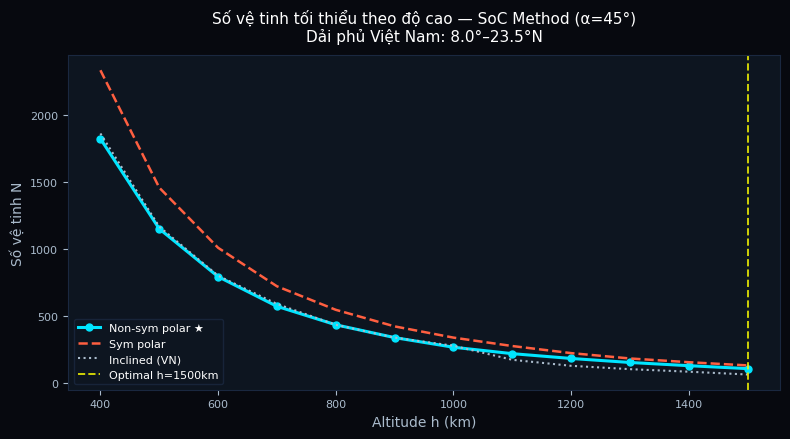

✓ Lưu: plot_N_vs_altitude.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=BG)
ax.set_facecolor(S1)

hs   = [r["h"]                         for r in sweep_rows]
Ns   = [r["nonsym"].get("N", np.nan)   for r in sweep_rows]
Ns2  = [r["sym"].get("N",    np.nan)   for r in sweep_rows]
Ni   = [r["inclined"].get("N", np.nan) for r in sweep_rows]

ax.plot(hs, Ns,  color=C1, lw=2.2, marker="o", ms=5, label="Non-sym polar ★")
ax.plot(hs, Ns2, color=C2, lw=1.8, ls="--",          label="Sym polar")
ax.plot(hs, Ni,  color=CG, lw=1.5, ls=":",            label="Inclined (VN)")
ax.axvline(optimal["h"], color="yellow", lw=1.4, ls="--", alpha=0.8,
           label=f"Optimal h={optimal['h']}km")

ax.set_xlabel("Altitude h (km)",  color=CG, fontsize=10)
ax.set_ylabel("Số vệ tinh N",     color=CG, fontsize=10)
ax.set_title(
    f"Số vệ tinh tối thiểu theo độ cao — SoC Method (α={ALPHA_DEG}°)\n"
    f"Dải phủ Việt Nam: {VN_LAT_MIN}°–{VN_LAT_MAX}°N",
    color="white", fontsize=11, pad=10)
ax.tick_params(colors=CG, labelsize=8)
ax.legend(fontsize=8, labelcolor="white", facecolor=S1, edgecolor="#1a2840")
for sp in ax.spines.values(): sp.set_edgecolor("#1a2840")

plt.tight_layout()
plt.savefig("plot_N_vs_altitude.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ Lưu: plot_N_vs_altitude.png")


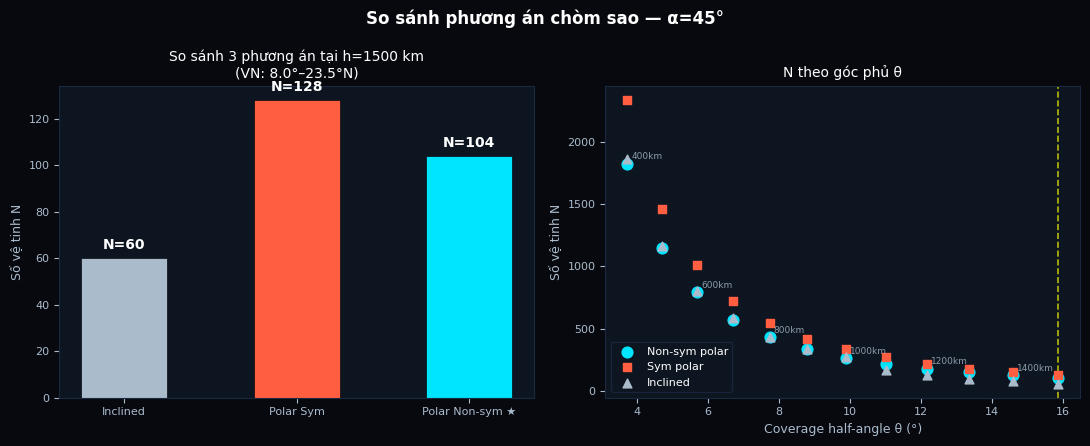

✓ Lưu: plot_constellation_compare.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor=BG)
h_opt = optimal["h"]
r_opt = next(r for r in sweep_rows if r["h"] == h_opt)

labels_bar = ["Inclined", "Polar Sym", "Polar Non-sym ★"]
vals_bar   = [r_opt["inclined"].get("N", 0),
              r_opt["sym"].get("N", 0),
              r_opt["nonsym"].get("N", 0)]
colors_bar = [CG, C2, C1]

# ── Bar ─────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor(S1)
bars = ax.bar(labels_bar, vals_bar, color=colors_bar,
              width=0.5, edgecolor=BG, linewidth=0.5)
for bar, v in zip(bars, vals_bar):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals_bar) * 0.02,
            f"N={int(v)}", ha="center", va="bottom",
            color="white", fontsize=10, fontweight="bold")
ax.set_ylabel("Số vệ tinh N", color=CG, fontsize=9)
ax.set_title(f"So sánh 3 phương án tại h={h_opt} km\n"
             f"(VN: {VN_LAT_MIN}°–{VN_LAT_MAX}°N)",
             color="white", fontsize=10)
ax.tick_params(colors=CG, labelsize=8)
for sp in ax.spines.values(): sp.set_edgecolor("#1a2840")

# ── Scatter N vs theta ───────────────────────────────────────
ax = axes[1]; ax.set_facecolor(S1)
thetas = [r["theta"] for r in sweep_rows]
ax.scatter(thetas, Ns,  color=C1, s=60, label="Non-sym polar", zorder=3)
ax.scatter(thetas, Ns2, color=C2, s=40, marker="s", label="Sym polar",  zorder=3)
ax.scatter(thetas, Ni,  color=CG, s=40, marker="^", label="Inclined",   zorder=3)
for r, n in zip(sweep_rows[::2], Ns[::2]):
    if not np.isnan(n):
        ax.annotate(f"{r['h']}km", xy=(r["theta"], n),
                    xytext=(3, 3), textcoords="offset points",
                    color=CG, fontsize=6.5, alpha=0.8)
ax.axvline(optimal["theta"], color="yellow", lw=1.2, ls="--", alpha=0.7)
ax.set_xlabel("Coverage half-angle θ (°)", color=CG, fontsize=9)
ax.set_ylabel("Số vệ tinh N",              color=CG, fontsize=9)
ax.set_title("N theo góc phủ θ",           color="white", fontsize=10)
ax.tick_params(colors=CG, labelsize=8)
ax.legend(fontsize=8, labelcolor="white", facecolor=S1, edgecolor="#1a2840")
for sp in ax.spines.values(): sp.set_edgecolor("#1a2840")

fig.suptitle(f"So sánh phương án chòm sao — α={ALPHA_DEG}°",
             color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_constellation_compare.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ Lưu: plot_constellation_compare.png")


In [ ]:
# Xác định loại chòm sao tối ưu
nonsym_flag = (type_opt == "nonsym")
i_deg_opt   = 90.0 if type_opt in ("nonsym", "sym") else cfg_opt.get("i", 90.0)

tle_list = build_constellation_tle(
    cfg_opt["n1"], cfg_opt["n2"], optimal["h"],
    i_deg=i_deg_opt, nonsym=nonsym_flag
)
print(f"▶ Sinh {len(tle_list)} TLE — n1={cfg_opt['n1']}, n2={cfg_opt['n2']}, "
      f"h={optimal['h']}km, i={i_deg_opt}°")
print("  3 TLE đầu tiên:")
for name, l1, l2 in tle_list[:3]:
    print(f"  {name}\n  {l1}\n  {l2}")

tle_filename = (f"tle_vn_h{optimal['h']}_"
                f"{cfg_opt['n1']}x{cfg_opt['n2']}.txt")
with open(tle_filename, "w", encoding="utf-8") as f:
    for name, l1, l2 in tle_list:
        f.write(f"{name}\n{l1}\n{l2}\n")
print(f"✓ Đã lưu TLE: {tle_filename}")

# ── Verify bằng Skyfield (elevation angle thực, loại bỏ 0–8°) ──
print(f"\n▶ Kiểm chứng Skyfield — dải [{VN_LAT_MIN}°, {VN_LAT_MAX}°N] ...")
verif = verify_vn(tle_list, optimal["theta"], optimal["h"], n_steps=24)

# Snapshot tại t0 để vẽ bản đồ
t0     = datetime(2026, 6, 1, 0, 0, 0, tzinfo=timezone.utc)
t0_sf  = _ts.from_datetime(t0)
lats_g = verif["lats"]
lons_g = verif["lons"]
lg, la = np.meshgrid(lons_g, lats_g)
pos_snap = get_positions(tle_list, _ts, t0_sf)
snap_cov = check_coverage_skyfield(tle_list, t0_sf, lats_g, lons_g,
                                   EL_MIN_DEG, VN_LAT_MIN, VN_LAT_MAX)
verif["snapshot"] = snap_cov

print(f"  avg coverage  : {verif['avg_pct']}%")
print(f"  min coverage  : {verif['min_pct']}%")
print(f"  full (≥99%)   : {verif['full_pct']}% thời gian")
print(f"  T_orbit       : {verif['T_orbit_min']} min")
print(f"  Throughput    : {verif['throughput_mbps']} Mbps")
print(f"  Contact time  : {verif['contact_sec']} s")
print(f"  Data/pass     : {verif['data_per_pass_gb']} GB  "
      f"({'✓ Imaging ok' if verif['imaging_ok'] else '✗ Dưới ngưỡng'})")


▶ Sinh 60 TLE — n1=3, n2=20, h=1500km, i=85.5°
  3 TLE đầu tiên:
  VNULEO-0001
  1 00001U 26001A   26001.50000000  .00000000  00000-0  00000-0 0  9990
  2 00001 085.5000 000.0000 0000001 000.0000 000.0000 12.41559304    10
  VNULEO-0002
  1 00002U 26001A   26001.50000000  .00000000  00000-0  00000-0 0  9990
  2 00002 085.5000 000.0000 0000001 000.0000 018.0000 12.41559304    20
  VNULEO-0003
  1 00003U 26001A   26001.50000000  .00000000  00000-0  00000-0 0  9990
  2 00003 085.5000 000.0000 0000001 000.0000 036.0000 12.41559304    30
✓ Đã lưu TLE: tle_vn_h1500_3x20.txt

▶ Kiểm chứng Skyfield — dải [8.0°, 23.5°N] ...


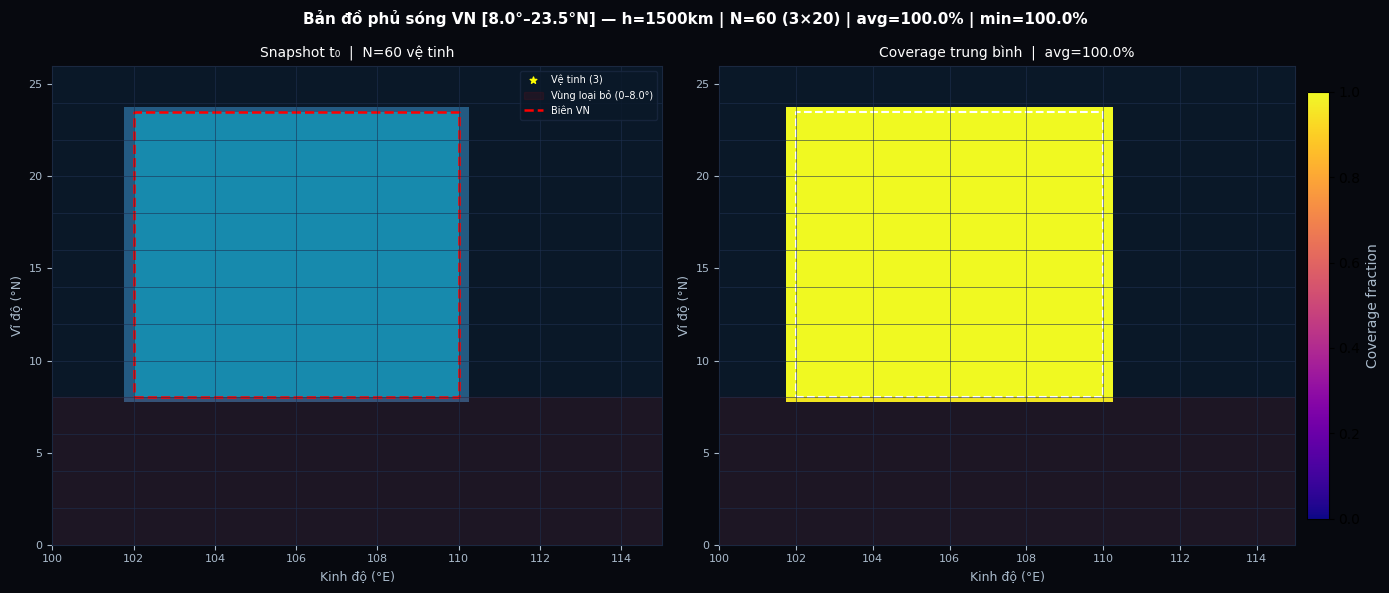

✓ Lưu: plot_coverage_map.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG)

cov_map = verif["snapshot"].astype(float)
avg_map = verif["avg_map"]

# ── Subplot A: Snapshot ──────────────────────────────────────
ax = axes[0]; ax.set_facecolor("#0a1828")
ax.pcolormesh(lg, la, cov_map,
              cmap="Blues", vmin=0, vmax=1.5, alpha=0.6, shading="auto")
ax.contourf(lg, la, cov_map, levels=[0.5, 1.5], colors=[C1], alpha=0.35)
ax.contour( lg, la, cov_map, levels=[0.5],       colors=[C1], linewidths=1.2)

# Vệ tinh gần VN
sat_lats = [p[0] for p in pos_snap]
sat_lons = [p[1] for p in pos_snap]
visible  = [(la_, lo_) for la_, lo_ in zip(sat_lats, sat_lons)
            if VN_LAT_MIN-15 <= la_ <= VN_LAT_MAX+15
            and VN_LON_MIN-15 <= lo_ <= VN_LON_MAX+15]
if visible:
    ax.scatter([p[1] for p in visible], [p[0] for p in visible],
               color="yellow", s=25, zorder=5, marker="*",
               label=f"Vệ tinh ({len(visible)})")

# Vùng loại bỏ (0–8°) — highlight để trực quan
ax.axhspan(0, VN_LAT_MIN, color="red", alpha=0.08,
           label=f"Vùng loại bỏ (0–{VN_LAT_MIN}°)")

ax.plot([VN_LON_MIN, VN_LON_MAX, VN_LON_MAX, VN_LON_MIN, VN_LON_MIN],
        [VN_LAT_MIN, VN_LAT_MIN, VN_LAT_MAX, VN_LAT_MAX, VN_LAT_MIN],
        "r--", lw=1.8, label="Biên VN")
for lo in np.arange(100, 115, 2): ax.axvline(lo, color="#1e3050", lw=0.4)
for la_ in np.arange(0,  28,  2): ax.axhline(la_, color="#1e3050", lw=0.4)
ax.set_xlim(100, 115); ax.set_ylim(0, 26)
ax.set_xlabel("Kinh độ (°E)", color=CG, fontsize=9)
ax.set_ylabel("Vĩ độ (°N)",   color=CG, fontsize=9)
ax.set_title(f"Snapshot t₀  |  N={cfg_opt['N']} vệ tinh",
             color="white", fontsize=10)
ax.tick_params(colors=CG, labelsize=8)
ax.legend(fontsize=7, labelcolor="white", facecolor="#0a1828", edgecolor="#1a2840")
for sp in ax.spines.values(): sp.set_edgecolor("#1a2840")

# ── Subplot B: Avg coverage map ──────────────────────────────
ax = axes[1]; ax.set_facecolor("#0a1828")
pcm = ax.pcolormesh(lg, la, avg_map, cmap="plasma",
                    vmin=0, vmax=1, shading="auto")
plt.colorbar(pcm, ax=ax, label="Coverage fraction",
             fraction=0.035, pad=0.02).ax.yaxis.label.set_color(CG)
ax.axhspan(0, VN_LAT_MIN, color="red", alpha=0.08)
ax.plot([VN_LON_MIN, VN_LON_MAX, VN_LON_MAX, VN_LON_MIN, VN_LON_MIN],
        [VN_LAT_MIN, VN_LAT_MIN, VN_LAT_MAX, VN_LAT_MAX, VN_LAT_MIN],
        "w--", lw=1.5)
for lo in np.arange(100, 115, 2): ax.axvline(lo, color="#1e3050", lw=0.4)
for la_ in np.arange(0,  28,  2): ax.axhline(la_, color="#1e3050", lw=0.4)
ax.set_xlim(100, 115); ax.set_ylim(0, 26)
ax.set_xlabel("Kinh độ (°E)", color=CG, fontsize=9)
ax.set_ylabel("Vĩ độ (°N)",   color=CG, fontsize=9)
ax.set_title(f"Coverage trung bình  |  avg={verif['avg_pct']}%",
             color="white", fontsize=10)
ax.tick_params(colors=CG, labelsize=8)
for sp in ax.spines.values(): sp.set_edgecolor("#1a2840")

fig.suptitle(
    f"Bản đồ phủ sóng VN [{VN_LAT_MIN}°–{VN_LAT_MAX}°N] — "
    f"h={optimal['h']}km | N={cfg_opt['N']} ({cfg_opt['n1']}×{cfg_opt['n2']}) | "
    f"avg={verif['avg_pct']}% | min={verif['min_pct']}%",
    color="white", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_coverage_map.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ Lưu: plot_coverage_map.png")


KeyError: 'throughput_mbps'

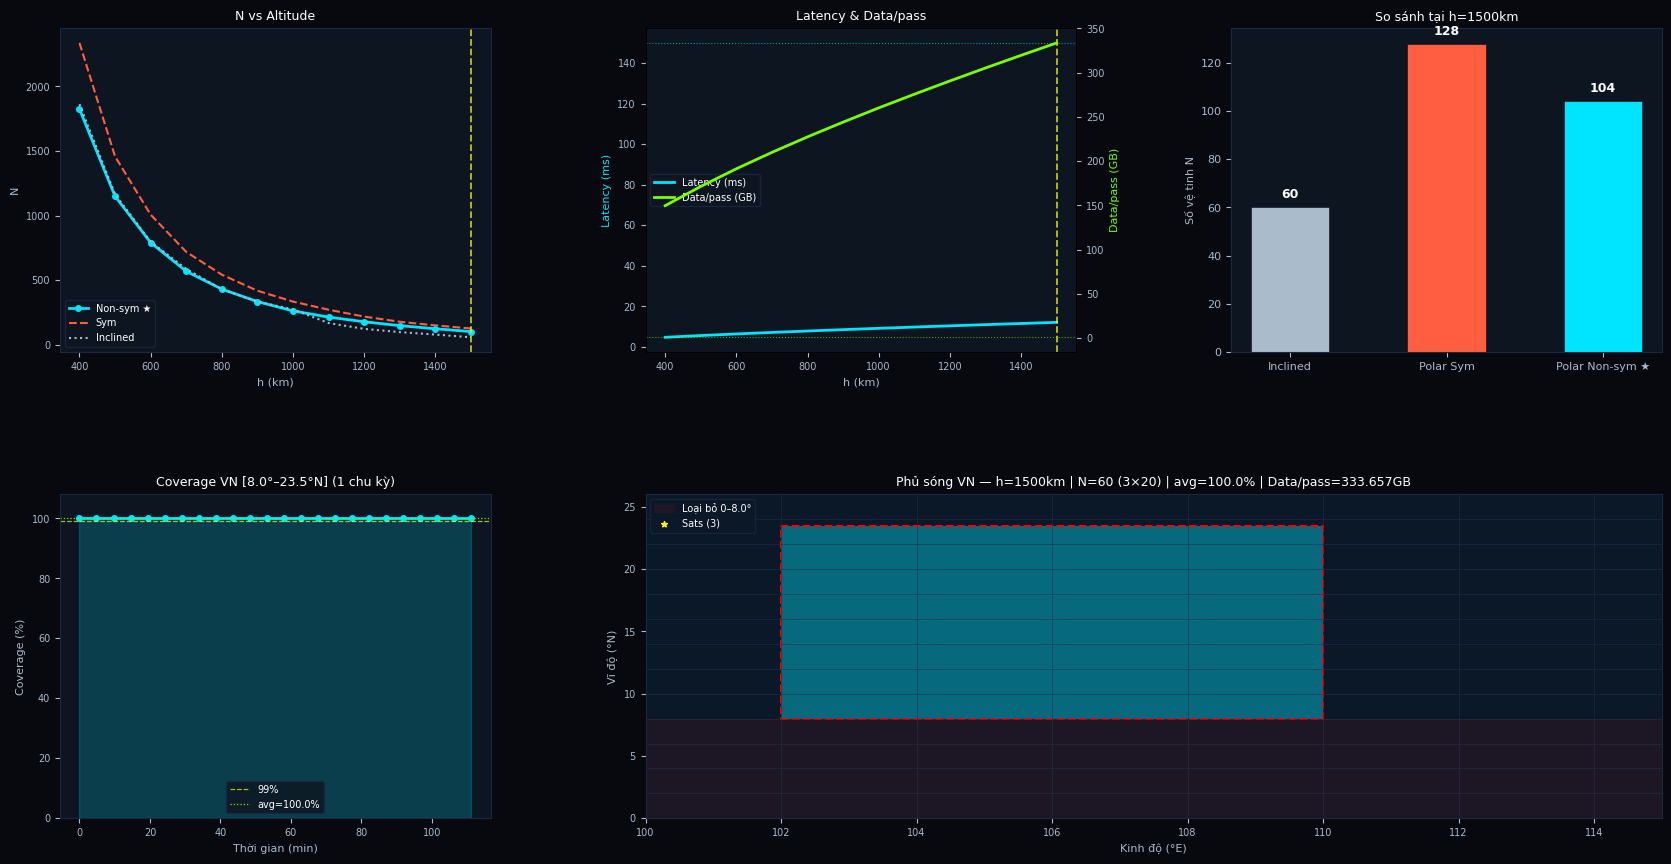

In [ ]:
tl   = verif["timeline"]
ts_x = [i * verif["dt_min"] for i in range(len(tl))]
lats_v = [latency_ms(h) for h in hs]
data_v = [data_per_pass_gb(h)[0] for h in hs]

fig = plt.figure(figsize=(18, 10), facecolor=BG)
gs  = gridspec.GridSpec(2, 3, figure=fig,
                         hspace=0.44, wspace=0.36,
                         left=0.07, right=0.96,
                         top=0.88, bottom=0.09)

# ── Panel 1: N vs h ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0]); ax1.set_facecolor(S1)
ax1.plot(hs, Ns,  color=C1, lw=2,   marker="o", ms=4, label="Non-sym ★")
ax1.plot(hs, Ns2, color=C2, lw=1.5, ls="--",          label="Sym")
ax1.plot(hs, Ni,  color=CG, lw=1.5, ls=":",            label="Inclined")
ax1.axvline(optimal["h"], color="yellow", lw=1.3, ls="--", alpha=0.75)
ax1.set_xlabel("h (km)",   color=CG, fontsize=8)
ax1.set_ylabel("N",        color=CG, fontsize=8)
ax1.set_title("N vs Altitude", color="white", fontsize=9)
ax1.tick_params(colors=CG, labelsize=7)
ax1.legend(fontsize=7, labelcolor="white", facecolor=S1, edgecolor="#1a2840")
for sp in ax1.spines.values(): sp.set_edgecolor("#1a2840")

# ── Panel 2: Latency & Data/pass ────────────────────────────
ax2  = fig.add_subplot(gs[0, 1]); ax2.set_facecolor(S1)
ax2b = ax2.twinx()
ax2.plot(hs, lats_v, color=C1, lw=2, label="Latency (ms)")
ax2b.plot(hs, data_v, color=C3, lw=2, label="Data/pass (GB)")
ax2.axhline(VOIP_MAX_LATENCY_MS,  color=C1, lw=0.8, ls=":", alpha=0.6)
ax2b.axhline(IMAGING_MIN_DATA_GB, color=C3, lw=0.8, ls=":", alpha=0.6)
ax2.axvline(optimal["h"], color="yellow", lw=1.3, ls="--", alpha=0.75)
ax2.set_xlabel("h (km)",          color=CG, fontsize=8)
ax2.set_ylabel("Latency (ms)",    color=C1, fontsize=8)
ax2b.set_ylabel("Data/pass (GB)", color=C3, fontsize=8)
ax2.set_title("Latency & Data/pass", color="white", fontsize=9)
ax2.tick_params(colors=CG, labelsize=7)
ax2b.tick_params(colors=CG, labelsize=7)
lines = (ax2.get_legend_handles_labels()[0] + ax2b.get_legend_handles_labels()[0])
labs  = (ax2.get_legend_handles_labels()[1] + ax2b.get_legend_handles_labels()[1])
ax2.legend(lines, labs, fontsize=7, labelcolor="white", facecolor=S1, edgecolor="#1a2840")
for sp in ax2.spines.values(): sp.set_edgecolor("#1a2840")

# ── Panel 3: Bar ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2]); ax3.set_facecolor(S1)
bars = ax3.bar(labels_bar, vals_bar, color=colors_bar,
               width=0.5, edgecolor=BG, linewidth=0.4)
for bar, v in zip(bars, vals_bar):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(vals_bar)*0.02,
             f"{int(v)}", ha="center", va="bottom",
             color="white", fontsize=9, fontweight="bold")
ax3.set_ylabel("Số vệ tinh N", color=CG, fontsize=8)
ax3.set_title(f"So sánh tại h={h_opt}km", color="white", fontsize=9)
ax3.tick_params(colors=CG, labelsize=8)
for sp in ax3.spines.values(): sp.set_edgecolor("#1a2840")

# ── Panel 4: Coverage timeline ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 0]); ax4.set_facecolor(S1)
ax4.fill_between(ts_x, tl, alpha=0.2, color=C1)
ax4.plot(ts_x, tl, color=C1, lw=2, marker="o", ms=4)
ax4.axhline(99.0, color="yellow", lw=0.9, ls="--", alpha=0.7, label="99%")
ax4.axhline(verif["avg_pct"], color=C3, lw=0.9, ls=":",  alpha=0.9,
            label=f"avg={verif['avg_pct']}%")
ax4.set_xlabel("Thời gian (min)", color=CG, fontsize=8)
ax4.set_ylabel("Coverage (%)",    color=CG, fontsize=8)
ax4.set_title(f"Coverage VN [{VN_LAT_MIN}°–{VN_LAT_MAX}°N] (1 chu kỳ)",
              color="white", fontsize=9)
ax4.set_ylim(0, 108)
ax4.tick_params(colors=CG, labelsize=7)
ax4.legend(fontsize=7, labelcolor="white", facecolor=S1, edgecolor="#1a2840")
for sp in ax4.spines.values(): sp.set_edgecolor("#1a2840")

# ── Panel 5–6: Coverage map ──────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1:]); ax5.set_facecolor("#0a1828")
ax5.contourf(lg, la, cov_map, levels=[0.5, 1.5], colors=[C1], alpha=0.40)
ax5.contour( lg, la, cov_map, levels=[0.5],       colors=[C1], linewidths=1.0)
ax5.axhspan(0, VN_LAT_MIN, color="red", alpha=0.08,
            label=f"Loại bỏ 0–{VN_LAT_MIN}°")
if visible:
    ax5.scatter([p[1] for p in visible], [p[0] for p in visible],
                color="yellow", s=18, marker="*", zorder=5,
                label=f"Sats ({len(visible)})")
ax5.plot([VN_LON_MIN, VN_LON_MAX, VN_LON_MAX, VN_LON_MIN, VN_LON_MIN],
         [VN_LAT_MIN, VN_LAT_MIN, VN_LAT_MAX, VN_LAT_MAX, VN_LAT_MIN],
         "r--", lw=1.5)
for lo in np.arange(100, 115, 2): ax5.axvline(lo, color="#1e3050", lw=0.4)
for la_ in np.arange(0,  28,  2): ax5.axhline(la_, color="#1e3050", lw=0.4)
ax5.set_xlim(100, 115); ax5.set_ylim(0, 26)
ax5.set_xlabel("Kinh độ (°E)", color=CG, fontsize=8)
ax5.set_ylabel("Vĩ độ (°N)",   color=CG, fontsize=8)
ax5.set_title(
    f"Phủ sóng VN — h={optimal['h']}km | N={cfg_opt['N']} "
    f"({cfg_opt['n1']}×{cfg_opt['n2']}) | "
    f"avg={verif['avg_pct']}% | Data/pass={verif['data_per_pass_gb']}GB",
    color="white", fontsize=9)
ax5.tick_params(colors=CG, labelsize=7)
ax5.legend(fontsize=7, labelcolor="white", facecolor="#0a1828", edgecolor="#1a2840")
for sp in ax5.spines.values(): sp.set_edgecolor("#1a2840")

fig.suptitle(
    f"VNU-LEO Dashboard  |  α={ALPHA_DEG}°  |  h={optimal['h']}km  |  "
    f"Dải VN: {VN_LAT_MIN}°–{VN_LAT_MAX}°N  |  "
    f"Latency={optimal['latency']}ms  |  Throughput={optimal['throughput_mbps']}Mbps",
    color="white", fontsize=11, fontweight="bold")

plt.savefig("vnu_leo_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("✓ Lưu: vnu_leo_dashboard.png")
